# ***MOUNTING & LOAD TRAIN MODEL***

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

xtrain = np.load('/content/drive/MyDrive/deepfake_dataset/xtrain.npy')
ytrain = np.load('/content/drive/MyDrive/deepfake_dataset/ytrain.npy')

xtest = np.load('/content/drive/MyDrive/deepfake_dataset/xtest.npy')
ytest = np.load('/content/drive/MyDrive/deepfake_dataset/ytest.npy')

xval = np.load('/content/drive/MyDrive/deepfake_dataset/xval.npy')
yval = np.load('/content/drive/MyDrive/deepfake_dataset/yval.npy')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/deepfake_model.h5')

In [ ]:
model.save('/content/drive/MyDrive/model.keras')

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential

# Load original model
model = load_model('/content/drive/MyDrive/deepfake_model.h5')

# 🔥 NEW CLEAN MODEL बनाओ
new_model = Sequential()

for layer in model.layers:
    new_model.add(layer)

# Compile again
new_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# SAVE CLEAN MODEL
new_model.save('/content/drive/MyDrive/deepfake_model.h5')

# ***IMPORTING LIBRARY***

In [ ]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt
import IPython
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Reshape,MaxPooling2D, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight


# ***DATASET LOADING***

In [ ]:
paths = []
labels = []

real_root_dir = '/content/drive/MyDrive/deepfake_dataset/release_in_the_wild/train/real'
fake_root_dir = '/content/drive/MyDrive/deepfake_dataset/release_in_the_wild/train/fake'

for filename in os.listdir(real_root_dir):
    if filename.endswith('.wav'):
        paths.append(os.path.join(real_root_dir, filename))
        labels.append('real')

for filename in os.listdir(fake_root_dir):
    if filename.endswith('.wav'):
        paths.append(os.path.join(fake_root_dir, filename))
        labels.append('fake')

print('Dataset is loaded')
print("Total files:", len(paths))

Dataset is loaded
Total files: 22245


In [ ]:
print(len(paths))

22245


In [ ]:
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels

In [ ]:
len(labels)

22245

In [ ]:
df['label'].value_counts()

,count
label,
real,13974
fake,8271


In [ ]:
real_audio = '/content/drive/MyDrive/deepfake_dataset/release_in_the_wild/train/real/100.wav'
fake_audio = '/content/drive/MyDrive/deepfake_dataset/release_in_the_wild/train/fake/1.wav'

In [ ]:
print('Real Audio:')
IPython.display.Audio(real_audio)

Real Audio:


In [ ]:
print('Fake Audio:')
IPython.display.Audio(fake_audio)

Fake Audio:


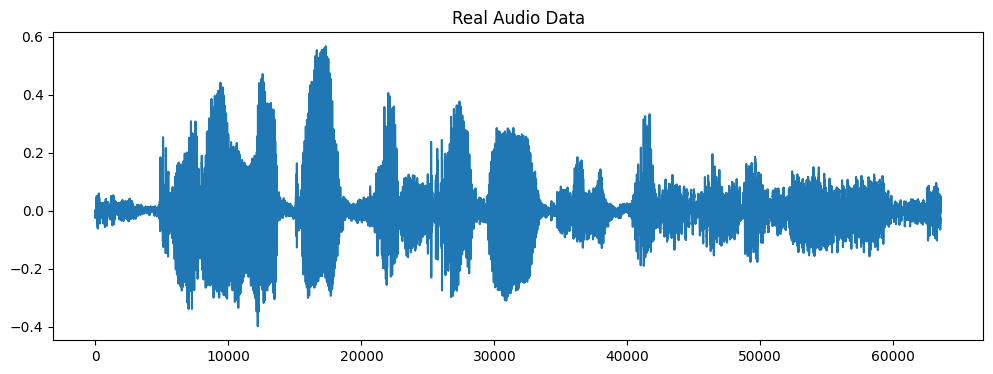

In [ ]:
real_ad, real_sr = librosa.load(real_audio)
plt.figure(figsize= (12,4))
plt.plot(real_ad)
plt.title('Real Audio Data')
plt.show()

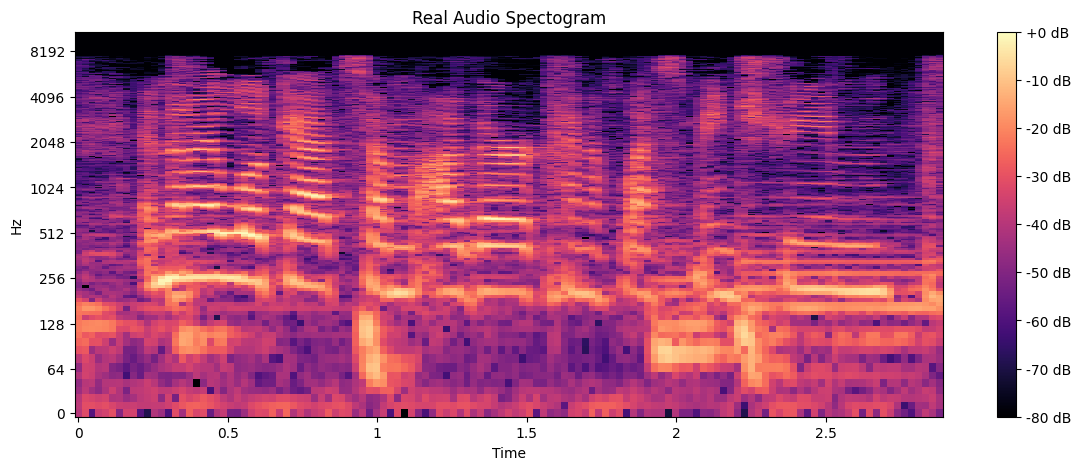

In [ ]:
real_spec = np.abs(librosa.stft(real_ad))
real_spec = librosa.amplitude_to_db(real_spec, ref = np.max)
plt.figure(figsize=(14,5))
librosa.display.specshow(real_spec, sr = real_sr, x_axis = 'time', y_axis = 'log')
plt.colorbar(format = '%+2.0f dB')
plt.title("Real Audio Spectogram")
plt.show()

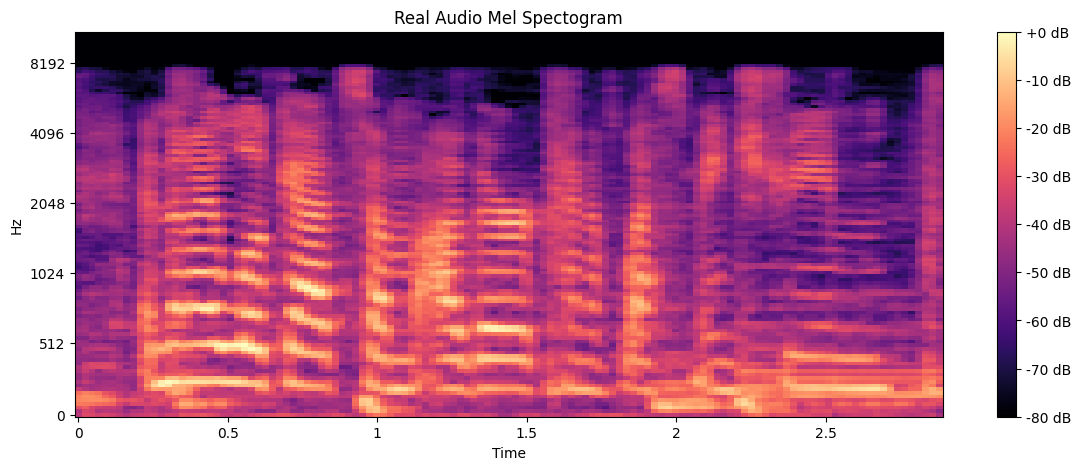

In [ ]:
real_mel_spect = librosa.feature.melspectrogram(y = real_ad, sr = real_sr)
real_mel_spect = librosa.power_to_db(real_mel_spect, ref = np.max)
plt.figure(figsize = (14,5))
librosa.display.specshow(real_mel_spect, y_axis ='mel', x_axis = 'time')
plt.title('Real Audio Mel Spectogram')
plt.colorbar(format = '%+2.0f dB')
plt.show()

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=994
  warnings.warn(


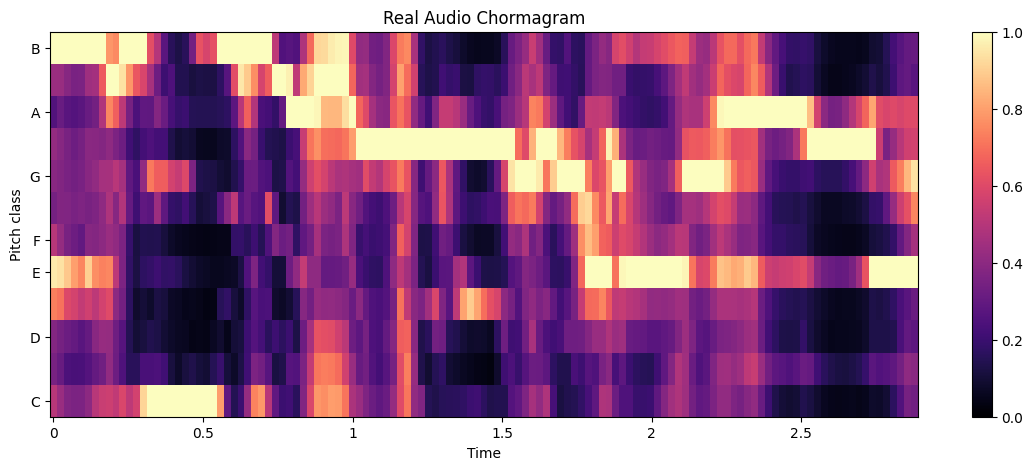

In [ ]:
real_chroma = librosa.feature.chroma_cqt(y = real_ad, sr = real_sr, bins_per_octave=36)
plt.figure(figsize = (14, 5))
librosa.display.specshow(real_chroma, sr = real_sr, x_axis = 'time', y_axis = 'chroma', vmin = 0, vmax = 1)
plt.colorbar()
plt.title('Real Audio Chormagram')
plt.show()

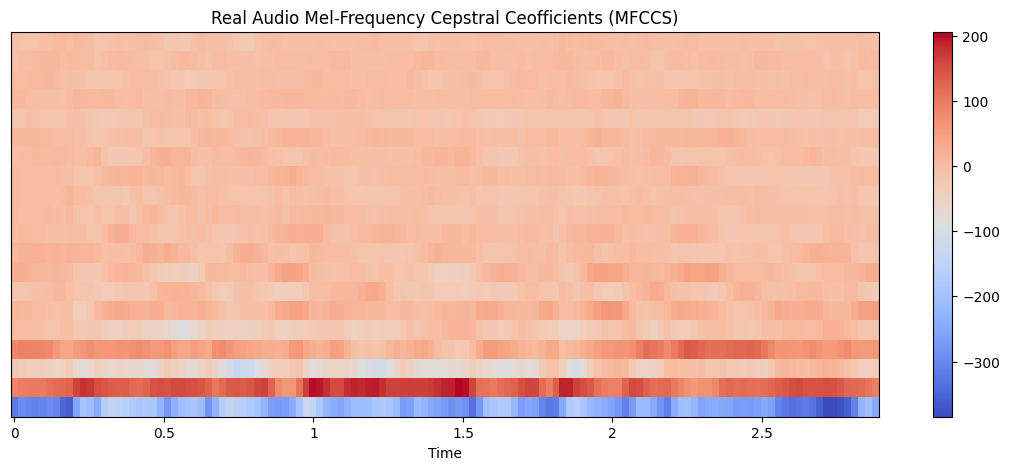

In [ ]:
real_mfcc = librosa.feature.mfcc(y = real_ad, sr = real_sr)
plt.figure(figsize = (14,5))
librosa.display.specshow(real_mfcc, sr = real_sr, x_axis ='time')
plt.colorbar()
plt.title('Real Audio Mel-Frequency Cepstral Ceofficients (MFCCS)')
plt.show()

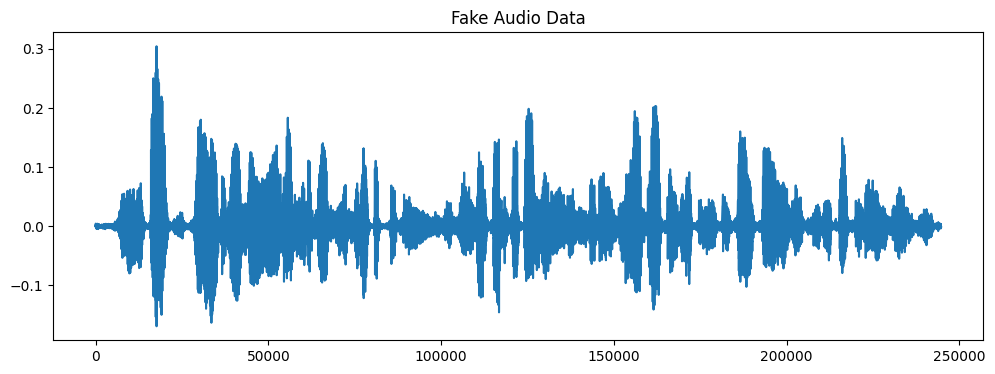

In [ ]:
fake_ad, fake_sr = librosa.load(fake_audio)
plt.figure(figsize =(12,4))
plt.plot(fake_ad)
plt.title("Fake Audio Data")
plt.show()

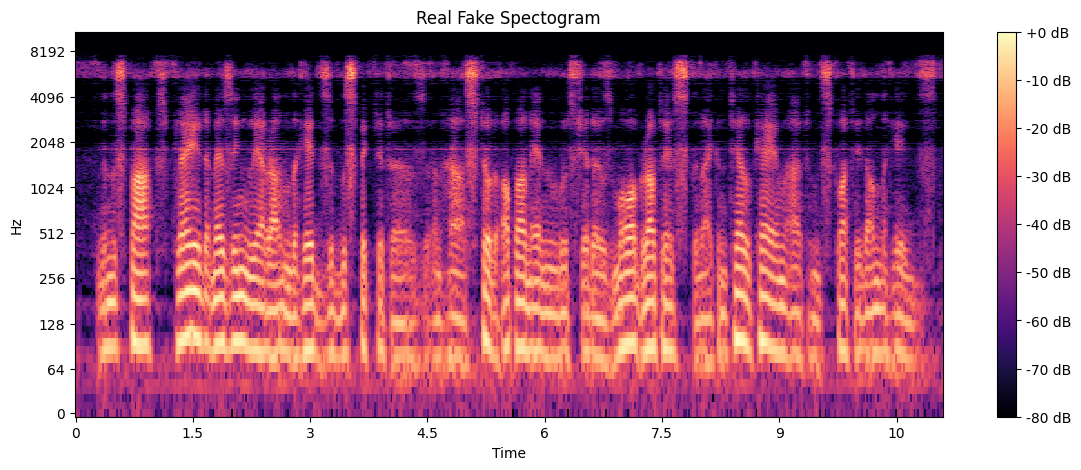

In [ ]:
fake_spec = np.abs(librosa.stft(fake_ad))
fake_spec = librosa.amplitude_to_db(fake_spec, ref = np.max)
plt.figure(figsize=(14,5))
librosa.display.specshow(fake_spec, sr = fake_sr, x_axis = 'time', y_axis = 'log')
plt.colorbar(format = '%+2.0f dB')
plt.title("Real Fake Spectogram")
plt.show()

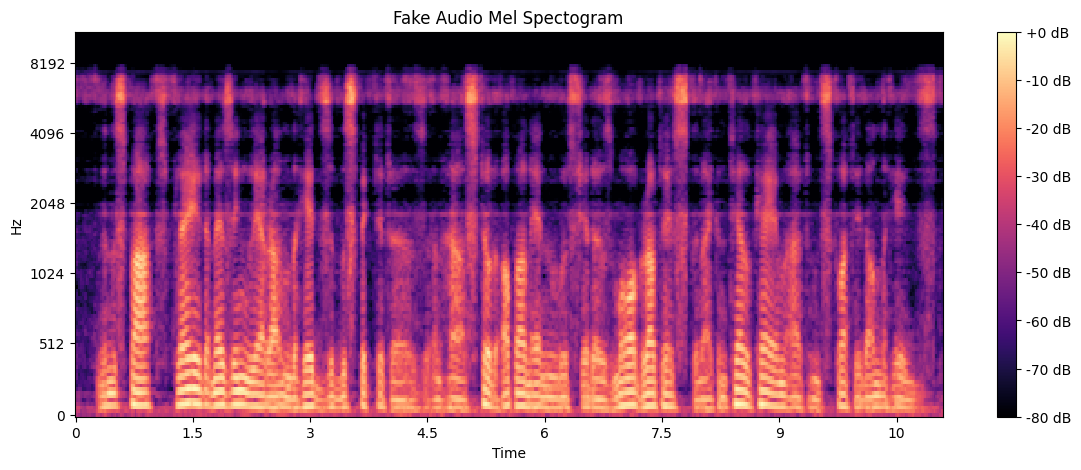

In [ ]:
fake_mel_spect = librosa.feature.melspectrogram(y = fake_ad, sr = fake_sr)
fake_mel_spect = librosa.power_to_db(fake_mel_spect, ref = np.max)
plt.figure(figsize = (14,5))
librosa.display.specshow(fake_mel_spect, y_axis ='mel', x_axis = 'time')
plt.title('Fake Audio Mel Spectogram')
plt.colorbar(format = '%+2.0f dB')
plt.show()

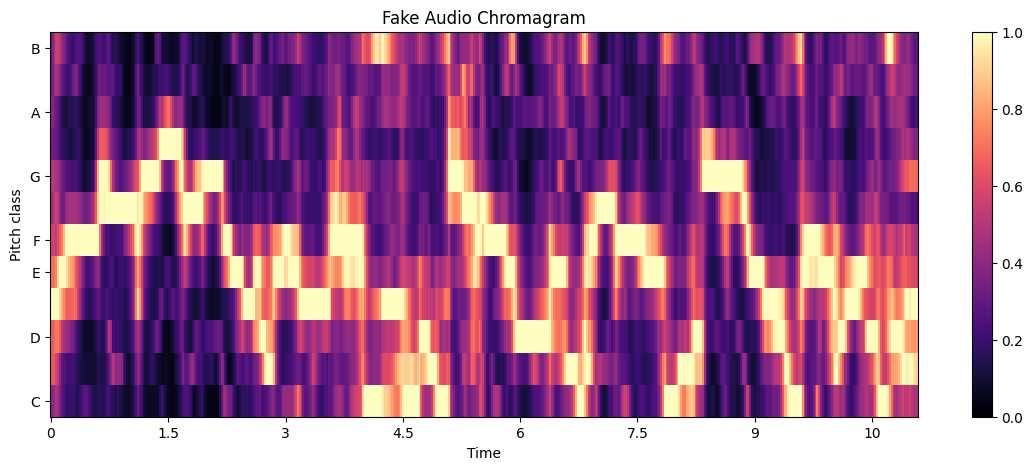

In [ ]:
fake_chroma = librosa.feature.chroma_cqt(y = fake_ad, sr = fake_sr, bins_per_octave=36)
plt.figure(figsize=(14,5))
librosa.display.specshow(fake_chroma, sr = fake_sr, x_axis= 'time', y_axis = 'chroma', vmin = 0, vmax = 1)
plt.colorbar()
plt.title('Fake Audio Chromagram')
plt.show()

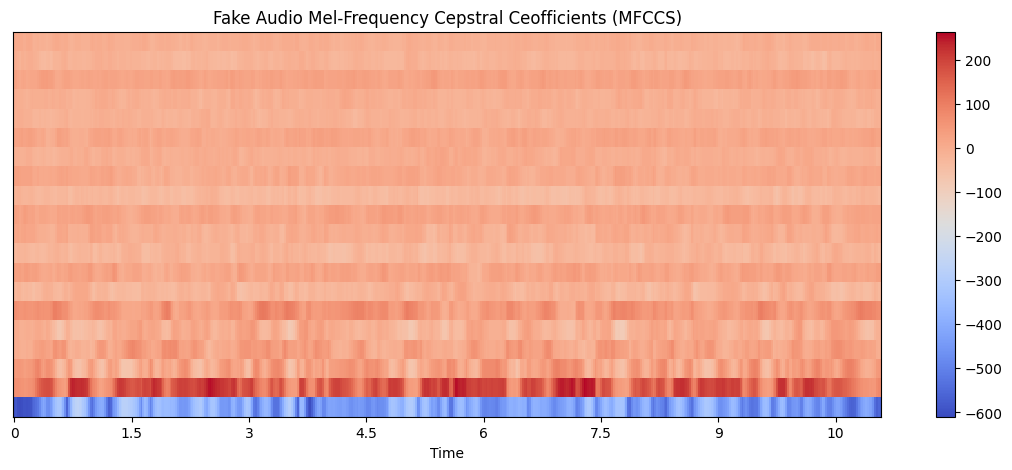

In [ ]:
fake_mfcc = librosa.feature.mfcc(y = fake_ad, sr = fake_sr)
plt.figure(figsize = (14,5))
librosa.display.specshow(fake_mfcc, sr = fake_sr, x_axis ='time')
plt.colorbar()
plt.title('Fake Audio Mel-Frequency Cepstral Ceofficients (MFCCS)')
plt.show()

# ***FEATURE EXTRACTION***

In [ ]:
def extract_features(fake_root_dir, real_root_dir, max_length=500):
    features = []
    labels = []

    for file in os.listdir(fake_root_dir):
        file_path = os.path.join(fake_root_dir, file)
        try:
            # Load audio file
            audio, _ = librosa.load(file_path, sr=16000)
            # Extract features (example: using Mel-Frequency Cepstral Coefficients)
            mfccs = librosa.feature.mfcc(y=audio, sr=16000, n_mfcc=40)
            # Pad or trim the feature array to a fixed length
            if mfccs.shape[1] < max_length:
                mfccs = np.pad(mfccs, ((0, 0), (0, max_length - mfccs.shape[1])), mode='constant')
            else:
                mfccs = mfccs[:, :max_length]
            features.append(mfccs)
            # Assign label
            labels.append(1)  # 1 for fake

        except Exception as e:
            print(f"Error encountered while parsing file: {file_path}")
            continue

    for file in os.listdir(real_root_dir):
        file_path = os.path.join(real_root_dir, file)
        try:
            # Load audio file
            audio, _ = librosa.load(file_path, sr=16000)
            # Extract features (example: using Mel-Frequency Cepstral Coefficients)
            mfccs = librosa.feature.mfcc(y=audio, sr=16000, n_mfcc=40)
            # Pad or trim the feature array to a fixed length
            if mfccs.shape[1] < max_length:
                mfccs = np.pad(mfccs, ((0, 0), (0, max_length - mfccs.shape[1])), mode='constant')
            else:
                mfccs = mfccs[:, :max_length]
            features.append(mfccs)
            # Assign label
            labels.append(0)  # 0 for real
        except Exception as e:
            print(f"Error encountered while parsing file: {file_path}")
            continue
    return np.array(features), np.array(labels)

# Example usage

x, y = extract_features(fake_root_dir, real_root_dir)

print("Features shape:", x.shape)
print("Labels shape:", y.shape)

# ***spliting***

In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: 80% train, 20% temp
xtrain, xtemp, ytrain, ytemp = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Step 2: 10% val, 10% test
xval, xtest, yval, ytest = train_test_split(
    xtemp, ytemp, test_size=0.5, random_state=42
)

NameError: name 'x' is not defined

# ***CLASS WEIGHT***

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(ytrain),
    y=ytrain
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

NameError: name 'ytrain' is not defined

## ***NEURAL NETWORK***

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers

model = Sequential([
        layers.Reshape((40, 500, 1), input_shape=xtrain.shape[1:]),
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Reshape((-1, 128)),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
        layers.BatchNormalization(),
        layers.Bidirectional(layers.LSTM(128, dropout=0.3, recurrent_dropout=0.2)),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Print the model summary to confirm the structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 40, 500, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 500, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 500, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 250, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 250, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 250, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 125, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 125, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 125, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 62, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 310, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 310, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 310, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 786,049 (3.00 MB)

 Trainable params: 784,577 (2.99 MB)

 Non-trainable params: 1,472 (5.75 KB)

# **AUTOMATICALLY SAVE MODEL DURING TRAINING***

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/deepfake_model.h5',  # direct Drive me save
    monitor='val_accuracy',
    save_best_only=True,   # sirf best model save hoga
    mode='max',
    verbose=1
)

# ***EARLY STOPPING***

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

# ***TRAINING***

In [ ]:
history = model.fit(
    xtrain, ytrain,
    validation_data=(xval, yval),
    epochs=50,
    batch_size=128,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7131 - loss: 0.7580
Epoch 1: val_accuracy improved from None to 0.42716, saving model to /content/drive/MyDrive/deepfake_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/deepfake_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.8165 - loss: 0.5775 - val_accuracy: 0.4272 - val_loss: 0.8872
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9327 - loss: 0.3187
Epoch 2: val_accuracy improved from 0.42716 to 0.96493, saving model to /content/drive/MyDrive/deepfake_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/deepfake_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 585s 4s/step - accuracy: 0.9384 - loss: 0.2982 - val_accuracy: 0.9649 - val_loss: 0.2480
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9587 - loss: 0.2246
Epoch 3: val_accuracy improved from 0.96493 to 0.96583, saving model to /content/drive/MyDrive/deepfake_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/deepfake_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 581s 4s/step - accuracy: 0.9599 - loss: 0.2186 - val_accuracy: 0.9658 - val_loss: 0.1866
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9670 - loss: 0.1803
Epoch 4: val_accuracy improved from 0.96583 to 0.97752, saving model to /content/drive/MyDrive/deepfake_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/deepfake_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 581s 4s/step - accuracy: 0.9683 - loss: 0.1736 - val_accuracy: 0.9775 - val_loss: 0.1385
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9722 - loss: 0.1514
Epoch 5: val_accuracy improved from 0.97752 to 0.98112, saving model to /content/drive/MyDrive/deepfake_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/deepfake_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.9730 - loss: 0.1437 - val_accuracy: 0.9811 - val_loss: 0.1138
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9786 - loss: 0.1179
Epoch 6: val_accuracy did not improve from 0.98112
140/140 ━━━━━━━━━━━━━━━━━━━━ 586s 4s/step - accuracy: 0.9779 - loss: 0.1148 - val_accuracy: 0.9415 - val_loss: 0.2123
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9809 - loss: 0.0950
Epoch 7: val_accuracy did not improve from 0.98112
140/140 ━━━━━━━━━━━━━━━━━━━━ 591s 4s/step - accuracy: 0.9815 - loss: 0.0929 - val_accuracy: 0.9789 - val_loss: 0.0935
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9861 - loss: 0.0689
Epoch 8: val_accuracy did not improve from 0.98112
140/140 ━━━━━━━━━━━━━━━━━━━━ 605s 4s/step - accuracy: 0.9857 - loss: 0.0676 - val_accuracy: 0.9775 - val_loss: 0.0882
Epoch 9/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4


Epoch 9: finished saving model to /content/drive/MyDrive/deepfake_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 573s 4s/step - accuracy: 0.9818 - loss: 0.0732 - val_accuracy: 0.9919 - val_loss: 0.0472
Epoch 10/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9896 - loss: 0.0499
Epoch 10: val_accuracy improved from 0.99191 to 0.99371, saving model to /content/drive/MyDrive/deepfake_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/deepfake_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 578s 4s/step - accuracy: 0.9897 - loss: 0.0497 - val_accuracy: 0.9937 - val_loss: 0.0421
Epoch 11/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9899 - loss: 0.0455
Epoch 11: val_accuracy did not improve from 0.99371
140/140 ━━━━━━━━━━━━━━━━━━━━ 577s 4s/step - accuracy: 0.9902 - loss: 0.0432 - val_accuracy: 0.9438 - val_loss: 0.1752
Epoch 12/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9887 - loss: 0.0425
Epoch 12: val_accuracy improved from 0.99371 to 0.99415, saving model to /content/drive/MyDrive/deepfake_model.h5



Epoch 12: finished saving model to /content/drive/MyDrive/deepfake_model.h5
140/140 ━━━━━━━━━━━━━━━━━━━━ 574s 4s/step - accuracy: 0.9908 - loss: 0.0393 - val_accuracy: 0.9942 - val_loss: 0.0323
Epoch 13/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9927 - loss: 0.0321
Epoch 13: val_accuracy did not improve from 0.99415
140/140 ━━━━━━━━━━━━━━━━━━━━ 618s 4s/step - accuracy: 0.9928 - loss: 0.0320 - val_accuracy: 0.9901 - val_loss: 0.0421
Epoch 14/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9921 - loss: 0.0344
Epoch 14: val_accuracy did not improve from 0.99415
140/140 ━━━━━━━━━━━━━━━━━━━━ 622s 4s/step - accuracy: 0.9930 - loss: 0.0310 - val_accuracy: 0.9888 - val_loss: 0.0466
Epoch 15/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9951 - loss: 0.0232
Epoch 15: val_accuracy did not improve from 0.99415
140/140 ━━━━━━━━━━━━━━━━━━━━ 571s 4s/step - accuracy: 0.9931 - loss: 0.0288 - val_accuracy: 0.9924 - val_loss: 0.0387
Epoch 16/50
140/140 ━━━━━━━━━━━━━━━━━

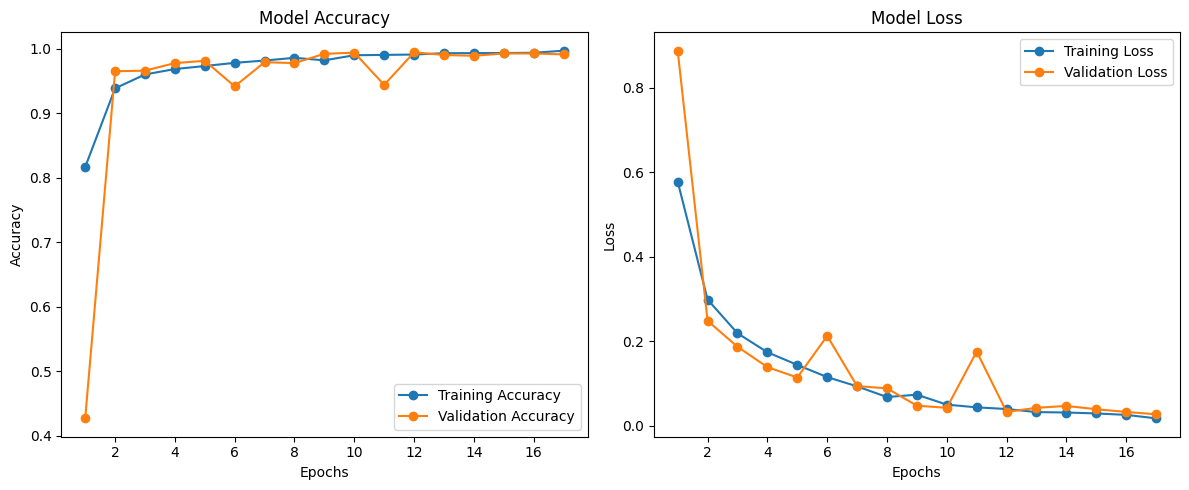

In [ ]:
import matplotlib.pyplot as plt

# Aapke training logs (Epoch 1 to 17) se uthayi gayi values
epochs = list(range(1, 18))
acc = [0.8165, 0.9384, 0.9599, 0.9683, 0.9730, 0.9779, 0.9815, 0.9857, 0.9818, 0.9897, 0.9902, 0.9908, 0.9928, 0.9930, 0.9931, 0.9935, 0.9967]
val_acc = [0.4272, 0.9649, 0.9658, 0.9775, 0.9811, 0.9415, 0.9789, 0.9775, 0.9919, 0.9937, 0.9438, 0.9942, 0.9901, 0.9888, 0.9924, 0.9924, 0.9910]
loss = [0.5775, 0.2982, 0.2186, 0.1736, 0.1437, 0.1148, 0.0929, 0.0676, 0.0732, 0.0497, 0.0432, 0.0393, 0.0320, 0.0310, 0.0288, 0.0254, 0.0172]
val_loss = [0.8872, 0.2480, 0.1866, 0.1385, 0.1138, 0.2123, 0.0935, 0.0882, 0.0472, 0.0421, 0.1752, 0.0323, 0.0421, 0.0466, 0.0387, 0.0324, 0.0267]

# Plotting Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ***SAVE FEATURE EXTRACTION***

In [ ]:
import numpy as np

np.save('/content/drive/MyDrive/deepfake_dataset/xtrain.npy', xtrain)
np.save('/content/drive/MyDrive/deepfake_dataset/ytrain.npy', ytrain)

np.save('/content/drive/MyDrive/deepfake_dataset/xval.npy', xval)
np.save('/content/drive/MyDrive/deepfake_dataset/yval.npy', yval)

np.save('/content/drive/MyDrive/deepfake_dataset/xtest.npy', xtest)
np.save('/content/drive/MyDrive/deepfake_dataset/ytest.npy', ytest)

# ***SAVE TRAINING MODEL***

In [ ]:
model.save('/content/drive/MyDrive/deepfake_model.h5')